# Class 2 — Alternative Measures of Volatility and Forecasting Evaluation

Range-based volatility, GK and OK measures, and a first nonlinear/predictive regression.

**Teaching note.** This notebook is intended to be run from top to bottom. Reusable data-loading and helper routines are in `course_tools.py`.


## Setup


In [1]:
# If needed:
# %pip install yfinance statsmodels scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import course_tools_general as ctg


# Download data for any ticker directly into your target variable
spx = ctg.load_prices(ticker="^GSPC", start="1990-01-01")
spx.head()

print(f"S&P 500 sample: {spx.index.min().date()} to {spx.index.max().date()}")


S&P 500 sample: 1990-01-02 to 2026-08-28


## Range Volatility

- We have information on High, Low, Open and Close prices.
- We put them in logarithmic form, \(h_t, l_t, o_t, c_t\).
- Garman--Klass (198) daily range volatility estimator:

$
\sigma_{GK,t}
=
\frac{1}{2}(h_t-l_t)^2
-
\left(2\ln 2 - 1\right)(c_t-o_t)^2
$

- \(n\)-period moving average of the Garman--Klass estimator:

$
\sigma^{MA,n}_{GK,t}
=
\frac{1}{n}
\sum_{i=0}^{n-1}
\sigma_{GK,t-i}
$
- For daily data we usually select n = 20
- The Bolerslev-Li-Li (2024) $\textbf{OK}$ range volatility estimator has the following form:

$\sigma_{OK,t}
=
0.811(h_t-l_t)^2
-
0.369\left|c_t-o_t\right|$

- The moving average is compued the same way, for a given horizon n:

  $
\sigma^{MA,n}_{OK,t}
=
\frac{1}{n}
\sum_{i=0}^{n-1}
\sigma_{BLL,t-i}
$

### References

- Garman, M. B., and Klass, M. J. (1980). "On the Estimation of Security Price Volatilities from Historical Data." *Journal of Business*, 53(1), 67--78.



- Bollerslev, T., Li, J., and Li, Y. (2024). "Realized Volatility and the High-Low Range." *Journal of Econometrics*, forthcoming.

  


In [2]:
hl = np.log(spx['High'] / spx['Low'])
co = np.log(spx['Close'] / spx['Open'])

gk = 0.5 * hl**2 - (2*np.log(2) - 1) * co**2

# Rolling mean of variance, then clip before sqrt
gk_10 = np.sqrt(pd.Series(gk).rolling(10).mean().clip(lower=0).to_numpy())
gk_15 = np.sqrt(pd.Series(gk).rolling(15).mean().clip(lower=0).to_numpy())
gk_20 = np.sqrt(pd.Series(gk).rolling(20).mean().clip(lower=0).to_numpy())

gk20 = gk_20

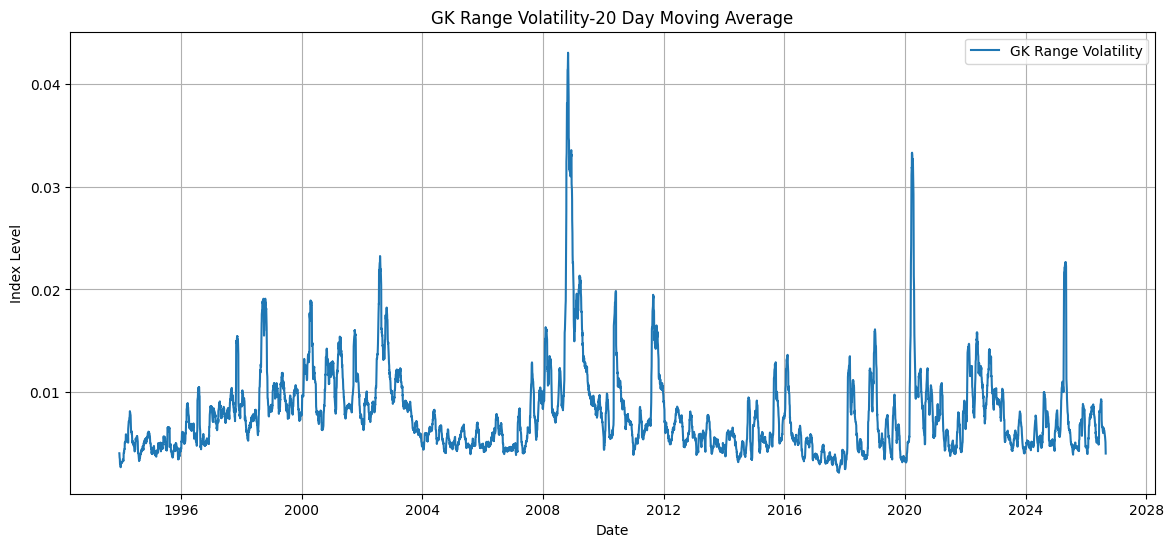

In [3]:
plt.figure(figsize=(14, 6))
plt.title("GK Range Volatility-20 Day Moving Average")
plt.plot(spx.index[1000:], gk20[1000:], label='GK Range Volatility')
plt.xlabel('Date')
plt.ylabel('Index Level')
plt.legend()
plt.grid()
plt.show()

## Bollerslev, Li and Li OK Range Volatility

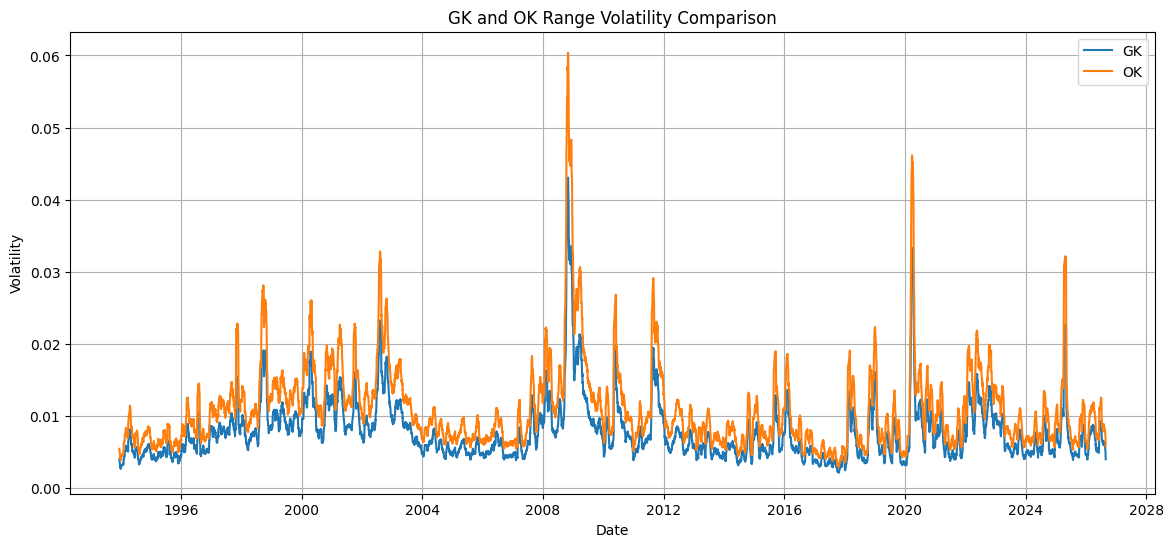

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── GK ──────────────────────────────────────────────────────────────────
hl = np.log(spx['High'] / spx['Low'])
co = np.log(spx['Close'] / spx['Open'])

gk = 0.5 * hl**2 - (2 * np.log(2) - 1) * co**2

gk_20 = np.sqrt(pd.Series(gk).rolling(20).mean().clip(lower=0).to_numpy())
gk20  = gk_20

# ── OK ──────────────────────────────────────────────────────────────────
# ── GK ──────────────────────────────────────────────────────────────────
hl  = np.log(spx['High'] / spx['Low'])
co  = np.log(spx['Close'] / spx['Open'])
gk  = 0.5 * hl**2 - (2 * np.log(2) - 1) * co**2

gk20 = np.sqrt(pd.Series(gk).rolling(20).mean().clip(lower=0).to_numpy())

# ── OK ──────────────────────────────────────────────────────────────────
w    = hl.copy()   # identical to hl
r_oc = co.copy()   # identical to co

ok_var = 0.811 * w**2 - 0.369 * r_oc**2

ok20 = np.sqrt(pd.Series(ok_var).rolling(20).mean().clip(lower=0).to_numpy())

# ── Plot ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 6))
plt.title("GK and OK Range Volatility Comparison")
plt.plot(spx.index[1000:], gk20[1000:], label='GK')
plt.plot(spx.index[1000:], ok20[1000:], label='OK')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid()
plt.savefig("gk_ok_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Plot ─────────────────────────────────────────────────────────────────



## Simple Regression with Feature Scaling

* We regress the return on **five lagged returns**. In machine-learning terminology, these explanatory variables or regressors are called **features**, **input variables**, or **predictors**.

* We divide the sample into a **training set** and an **out-of-sample test set**.

* The training set contains the first **80 percent** of the observations, while the test set contains the final **20 percent**.

* Since this is time-series data, we preserve the chronological ordering of the observations. We do **not** randomly shuffle the data before making the training/test split.

* It is also common in machine learning to **scale** or **normalize** the features. One commonly used transformation is the **Min-Max scaler**, which transforms a variable to lie within a specified range.

* The Min-Max transformation that scales a feature $x$ to the range $[a,b]$ is

$$
x_{\text{scaled}}
=
a+
\frac{x-x_{\min}}
{x_{\max}-x_{\min}}
(b-a).
$$

* For the commonly used range $[0,1]$, the transformation becomes

$$
x_{\text{scaled}}
=
\frac{x-x_{\min}}
{x_{\max}-x_{\min}}.
$$

* The values of $x_{\min}$ and $x_{\max}$ should be calculated using the **training sample only**. The same transformation is then applied to the test sample. This avoids using information from the test sample when estimating the model.

* For a simple linear regression, Min-Max scaling will generally **not change the fitted values or predictive accuracy**, provided the transformation is applied consistently. It simply changes the units in which the estimated coefficients are expressed.

* Scaling becomes much more important when we move to nonlinear machine-learning methods. For many numerical optimization algorithms, neural networks, and regularization methods, having the features on similar scales can improve numerical stability and speed convergence.

---

## Out-of-Sample Prediction

We estimate a simple regression of the return on its five lagged values using the first 80 percent of the sample.

The estimated coefficients from the training sample are then used to predict returns in the remaining 20 percent of the sample.

Our primary concern here is **not whether the individual regression coefficients are statistically significant**. Instead, we are interested in the model's **out-of-sample predictive accuracy**.

To evaluate predictive accuracy, we use the **Root Mean Squared Error (RMSE)**.

Let $N^*$ denote the number of observations in the out-of-sample test set. Let $y_{\text{test},t^*}$ denote the actual return and $\hat{y}_{\text{test},t^*}$ denote the return predicted using the model estimated on the training sample.

The RMSE is

$$
RMSE
=
\sqrt{
\frac{
\sum_{t^*=1}^{N^*}
\left(
y_{\text{test},t^*}
-
\hat{y}_{\text{test},t^*}
\right)^2
}{
N^*
}
}.
$$

A smaller RMSE indicates better out-of-sample predictive accuracy.

---

## Why Out-of-Sample Prediction Matters

* The RMSE has limited meaning when considered entirely by itself. It becomes especially useful when **comparing the predictive accuracy of competing models**.

* For example, we may compare models containing different regressors, different numbers of lags, or entirely different machine-learning methods.

* Out-of-sample evaluation provides an important discipline against **overfitting**.

* We can include many regressors, or **features**, and obtain an excellent in-sample fit. However, a model that fits the training data extremely well may perform poorly when asked to predict observations that were not used in estimating the model.

* This is the danger of *overfitting*.

* The problem is closely related to the **bias--variance tradeoff**.

* A more flexible model with many predictors may reduce bias and improve its fit to the training data. At the same time, greater model complexity can increase variance: the estimated model may become highly sensitive to the particular observations contained in the training sample.

* Consequently, a model with a very good in-sample fit may have relatively poor out-of-sample predictive performance.

* The goal in machine learning is therefore not simply to obtain the best possible fit to the training data. The goal is to construct a model that **generalizes well to new observations**.

In short,

$$
\text{good in-sample fit}
\;\not\Rightarrow\;
\text{good out-of-sample prediction}.
$$

Out-of-sample measures such as the RMSE help us determine whether an apparently successful model is actually capable of predicting new data.


## Random Walk Benchmark

A useful benchmark for forecasting financial prices and exchange rates is the **random walk hypothesis**.

Suppose the exchange-rate level at date $t$ is $S_t$.

Under the random walk hypothesis,

$$
S_{t+1}
=
S_t
+
\varepsilon_{t+1},
$$

where $\varepsilon_{t+1}$ is an unpredictable innovation with

$$
E_t(\varepsilon_{t+1})=0.
$$

Therefore, the best forecast of tomorrow's exchange rate using information available today is simply today's exchange rate:

$$
\hat{S}_{t+1|t}
=
S_t.
$$

In other words,

$$
E_t(S_{t+1})
=
S_t.
$$

The random walk hypothesis therefore implies that changes in the exchange rate are unpredictable.

Define the change in the exchange rate as

$$
\Delta S_{t+1}
=
S_{t+1}
-
S_t.
$$

Under the random walk hypothesis,

$$
\Delta S_{t+1}
=
\varepsilon_{t+1},
$$

and therefore the best forecast of tomorrow's change is

$$
\widehat{\Delta S}_{t+1|t}
=
0.
$$

---

## Random Walk in Terms of Returns

If we work with returns rather than the exchange-rate level, the corresponding random-walk benchmark is that tomorrow's expected return is zero:

$$
\hat{r}_{t+1|t}
=
0.
$$

Thus, the random-walk model uses no lagged returns, volatility measures, or other predictors.

Its forecast is simply

$$
\boxed{
\hat{r}_{t+1}=0
}
$$

for every observation in the out-of-sample test set.

---

## Why Use the Random Walk as a Benchmark?

The random walk provides a simple benchmark against which more complicated forecasting models can be evaluated.

We compare the out-of-sample RMSE from the random walk with the RMSE from models such as

$$
r_{t+1}
=
\alpha
+
\beta_1 r_t
+
\beta_2 r_{t-1}
+
\cdots
+
\beta_5 r_{t-4}
+
\varepsilon_{t+1},
$$

and

$$
r_{t+1}
=
\alpha
+
\beta_1 r_t
+
\beta_2 r_{t-1}
+
\cdots
+
\beta_5 r_{t-4}
+
\gamma OK20_t
+
\varepsilon_{t+1}.
$$

The comparison is therefore

$$
RMSE_{\text{Random Walk}},
$$

$$
RMSE_{\text{AR(5)}},
$$

and

$$
RMSE_{\text{AR(5)+OK20}}.
$$

If

$$
RMSE_{\text{AR(5)+OK20}}
<
RMSE_{\text{Random Walk}},
$$

then the additional predictors provide useful out-of-sample forecasting information.

If the more complicated model does not produce a lower RMSE than the random walk, then the additional predictors have not improved predictive accuracy.

---

## Main Interpretation

The random walk is intentionally a very simple forecasting rule.

Its importance comes from the fact that many financial prices, particularly exchange rates, are difficult to forecast consistently.

Therefore, a useful standard for evaluating a forecasting model is not simply whether it fits the historical data well, but whether it can outperform the random-walk benchmark in genuine out-of-sample prediction.

In short,

$$
\text{a forecasting model is useful only if it can beat a simple benchmark out of sample.}
$$


In [27]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

nlags = 5

# Convert returns to NumPy array
r = spx['Return'].dropna().to_numpy()

# y_t starts at t = nlags
y = r[nlags:]

# Lag matrix: r_{t-1}, ..., r_{t-5}
X = np.column_stack([
    r[nlags - i - 1 : -i - 1] for i in range(nlags)
])

# Create 4 dummies (Monday omitted)


# Append dummies to existing lag matrix
X = np.column_stack([X])

print(X.shape)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_normalized = scaler_X.fit_transform(X)

# y is now NumPy, so reshape works
y_normalized = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

train_size = int(0.8 * len(y))

x_train = X_normalized[:train_size]
x_test  = X_normalized[train_size:]

y_train = y_normalized[:train_size]
y_test  = y_normalized[train_size:]

x_train_with_const = sm.add_constant(x_train)
x_test_with_const  = sm.add_constant(x_test)

model = sm.OLS(y_train, x_train_with_const).fit()

predicted_train = model.predict(x_train_with_const)
predicted_test  = model.predict(x_test_with_const)

error_ols = y_test - predicted_test

mse_train_ols = mean_squared_error(y_train, predicted_train)
mse_test_ols  = mean_squared_error(y_test, predicted_test)

print(model.summary())
print(f"OLS Linear Regression MSE on Training Data: {mse_train_ols:.6f}")
print(f"OLS Linear Regression MSE on Test Data: {mse_test_ols:.6f}")

(9226, 5)
Shape of X: (9226, 5)
Shape of y: (9226,)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     10.05
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.31e-09
Time:                        14:04:28   Log-Likelihood:                 12187.
No. Observations:                7380   AIC:                        -2.436e+04
Df Residuals:                    7374   BIC:                        -2.432e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


In [11]:
[len(ok20), len(r)]
#len(r)

[9232, 9231]

In [28]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler


# ============================================================
# SETTINGS
# ============================================================

nlags = 5


# ============================================================
# 1. ALIGN RETURNS AND OK20
# ============================================================

# Return series
# The first observation is missing because returns involve
# a first difference of the stock-price series.

returns = spx["Return"].dropna()

print("Number of return observations:", len(returns))
print("Number of OK20 observations:  ", len(ok20))


# OK20 is a NumPy array and has one more observation
# than the return series.
#
# Drop the first OK20 observation so that:
#
# Return_t <--> OK20_t

ok20_aligned = ok20[1:]


# Check that the lengths now agree

print("Length after alignment:")
print("Returns:", len(returns))
print("OK20:   ", len(ok20_aligned))


# Convert OK20 to a pandas Series using the return dates

volatility = pd.Series(
    ok20_aligned,
    index=returns.index,
    name="OK20"
)


# Put returns and volatility into one DataFrame

data = pd.DataFrame({
    "Return": returns,
    "OK20": volatility
})

print("\nFirst observations:")
print(data.head())


# ============================================================
# 2. CREATE FIVE LAGS OF RETURNS
# ============================================================

for lag in range(1, nlags + 1):

    data[f"Return_Lag{lag}"] = (
        data["Return"].shift(lag)
    )


# ============================================================
# 3. CREATE ONE LAG OF OK20
# ============================================================

# We use yesterday's volatility to predict today's return.
#
# This gives the forecasting equation:
#
# Return_t =
# alpha
# + beta1 Return_{t-1}
# + ...
# + beta5 Return_{t-5}
# + gamma OK20_{t-1}
# + error_t

data["OK20_Lag1"] = data["OK20"].shift(1)


# Remove observations lost because of lagging

data = data.dropna()

print("\nNumber of usable observations:", len(data))

print("\nData used in regressions:")
print(data.head())


# ============================================================
# 4. DEFINE DEPENDENT VARIABLE
# ============================================================

y = data["Return"]


# ============================================================
# 5. DEFINE FEATURES FOR THE TWO MODELS
# ============================================================

return_features = [
    "Return_Lag1",
    "Return_Lag2",
    "Return_Lag3",
    "Return_Lag4",
    "Return_Lag5"
]


# MODEL 1:
# Five lagged returns only

X_base = data[
    return_features
]


# MODEL 2:
# Five lagged returns plus lagged OK20

X_vol = data[
    return_features + ["OK20_Lag1"]
]


# ============================================================
# 6. TRAINING / TEST SPLIT
# ============================================================

# First 80 percent = training sample
# Last 20 percent  = out-of-sample test sample

train_size = int(
    0.8 * len(data)
)

print("\nTraining observations:", train_size)

print(
    "Test observations:    ",
    len(data) - train_size
)


# Split y

y_train_raw = y.iloc[:train_size]
y_test_raw  = y.iloc[train_size:]


# ============================================================
# 7. NORMALIZE y
# ============================================================

# IMPORTANT:
# Fit the scaler using TRAINING observations only.

scaler_y = MinMaxScaler()


y_train = scaler_y.fit_transform(
    y_train_raw
    .to_numpy()
    .reshape(-1, 1)
).flatten()


# Apply the SAME training transformation
# to the test observations.

y_test = scaler_y.transform(
    y_test_raw
    .to_numpy()
    .reshape(-1, 1)
).flatten()


# ============================================================
# 8. FUNCTION TO ESTIMATE A MODEL
# ============================================================

def estimate_model(X, model_name):


    # --------------------------------------------------------
    # Divide X into training and test samples
    # --------------------------------------------------------

    X_train_raw = X.iloc[:train_size]

    X_test_raw = X.iloc[train_size:]


    # --------------------------------------------------------
    # Normalize X
    # --------------------------------------------------------

    # Fit scaler using training observations only

    scaler_X = MinMaxScaler()


    X_train_scaled = scaler_X.fit_transform(
        X_train_raw
    )


    # Apply SAME scaler to test data

    X_test_scaled = scaler_X.transform(
        X_test_raw
    )


    # --------------------------------------------------------
    # Convert back to DataFrames
    # so regression output keeps variable names
    # --------------------------------------------------------

    X_train = pd.DataFrame(
        X_train_scaled,
        columns=X.columns,
        index=X_train_raw.index
    )


    X_test = pd.DataFrame(
        X_test_scaled,
        columns=X.columns,
        index=X_test_raw.index
    )


    # --------------------------------------------------------
    # Add intercept
    # --------------------------------------------------------

    X_train = sm.add_constant(
        X_train
    )

    X_test = sm.add_constant(
        X_test
    )


    # --------------------------------------------------------
    # Estimate OLS using TRAINING sample
    # --------------------------------------------------------

    model = sm.OLS(
        y_train,
        X_train
    ).fit()


    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    predicted_train_scaled = model.predict(
        X_train
    )

    predicted_test_scaled = model.predict(
        X_test
    )


    # --------------------------------------------------------
    # Convert predictions back to ORIGINAL RETURN UNITS
    # --------------------------------------------------------

    predicted_train = (
        scaler_y
        .inverse_transform(
            np.asarray(
                predicted_train_scaled
            ).reshape(-1, 1)
        )
        .flatten()
    )


    predicted_test = (
        scaler_y
        .inverse_transform(
            np.asarray(
                predicted_test_scaled
            ).reshape(-1, 1)
        )
        .flatten()
    )


    # --------------------------------------------------------
    # Calculate prediction errors
    # --------------------------------------------------------

    error_train = (
        y_train_raw.to_numpy()
        - predicted_train
    )


    error_test = (
        y_test_raw.to_numpy()
        - predicted_test
    )


    # --------------------------------------------------------
    # MSE
    # --------------------------------------------------------

    mse_train = mean_squared_error(
        y_train_raw,
        predicted_train
    )


    mse_test = mean_squared_error(
        y_test_raw,
        predicted_test
    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse_train = np.sqrt(
        mse_train
    )


    rmse_test = np.sqrt(
        mse_test
    )


    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print("\n")
    print("=" * 75)
    print(model_name)
    print("=" * 75)

    print(model.summary())

    print(
        f"\nTraining RMSE: {rmse_train:.6f}"
    )

    print(
        f"Test RMSE:     {rmse_test:.6f}"
    )


    # --------------------------------------------------------
    # Return results
    # --------------------------------------------------------

    return {
        "model": model,
        "predicted_train": predicted_train,
        "predicted_test": predicted_test,
        "error_train": error_train,
        "error_test": error_test,
        "mse_train": mse_train,
        "mse_test": mse_test,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test
    }


# ============================================================
# 9. MODEL 1: FIVE RETURN LAGS
# ============================================================

base_results = estimate_model(

    X_base,

    "MODEL 1: FIVE LAGGED RETURNS"
)


# ============================================================
# 10. MODEL 2: FIVE RETURN LAGS + OK20
# ============================================================

vol_results = estimate_model(

    X_vol,

    "MODEL 2: FIVE LAGGED RETURNS + LAGGED OK20"
)


# ============================================================
# 11. COMPARE OUT-OF-SAMPLE PREDICTIVE ACCURACY
# ============================================================

rmse_base = base_results[
    "rmse_test"
]

rmse_vol = vol_results[
    "rmse_test"
]


print("\n")
print("=" * 60)
print("OUT-OF-SAMPLE PREDICTIVE ACCURACY")
print("=" * 60)


print(
    f"Five lagged returns:           {rmse_base:.6f}"
)


print(
    f"Five lags + lagged OK20:       {rmse_vol:.6f}"
)


# Percentage improvement from adding OK20

percent_improvement = (

    100
    * (rmse_base - rmse_vol)
    / rmse_base

)


print(
    f"Percent RMSE improvement:      "
    f"{percent_improvement:.2f}%"
)


# ============================================================
# 12. INDICATE WHICH MODEL PREDICTS BETTER
# ============================================================

if rmse_vol < rmse_base:

    print(
        "\nAdding OK20 IMPROVES "
        "out-of-sample predictive accuracy."
    )

else:

    print(
        "\nAdding OK20 DOES NOT improve "
        "out-of-sample predictive accuracy."
    )

Number of return observations: 9231
Number of OK20 observations:   9232
Length after alignment:
Returns: 9231
OK20:    9231

First observations:
              Return  OK20
Date                      
1990-01-03 -0.002589   NaN
1990-01-04 -0.008650   NaN
1990-01-05 -0.009804   NaN
1990-01-08  0.004504   NaN
1990-01-09 -0.011857   NaN

Number of usable observations: 9212

Data used in regressions:
              Return      OK20  Return_Lag1  Return_Lag2  Return_Lag3  \
Date                                                                    
1990-01-30 -0.006850  0.014061    -0.001843    -0.000859    -0.012738   
1990-01-31  0.018710  0.014258    -0.006850    -0.001843    -0.000859   
1990-02-01 -0.000882  0.013974     0.018710    -0.006850    -0.001843   
1990-02-02  0.006457  0.014008    -0.000882     0.018710    -0.006850   
1990-02-05  0.002806  0.013894     0.006457    -0.000882     0.018710   

            Return_Lag4  Return_Lag5  OK20_Lag1  
Date                                    

In [29]:
# ============================================================
# 13. RANDOM-WALK / ZERO-RETURN BENCHMARK
# ============================================================

# Under the random-walk hypothesis, the best forecast
# of tomorrow's change is zero.
#
# Therefore, if the dependent variable is the return:
#
# predicted return = 0

predicted_random_walk = np.zeros(len(y_test_raw))


# Calculate out-of-sample MSE

mse_random_walk = mean_squared_error(
    y_test_raw,
    predicted_random_walk
)


# Calculate out-of-sample RMSE

rmse_random_walk = np.sqrt(
    mse_random_walk
)


# ============================================================
# 14. COMPARE ALL THREE MODELS
# ============================================================

print("\n")
print("=" * 65)
print("OUT-OF-SAMPLE PREDICTIVE ACCURACY")
print("=" * 65)

print(
    f"Random walk / zero-return forecast:  "
    f"{rmse_random_walk:.6f}"
)

print(
    f"Five lagged returns:                 "
    f"{rmse_base:.6f}"
)

print(
    f"Five return lags + lagged OK20:      "
    f"{rmse_vol:.6f}"
)


# ============================================================
# 15. DETERMINE BEST MODEL
# ============================================================

rmse_results = {
    "Random Walk": rmse_random_walk,
    "Five Return Lags": rmse_base,
    "Five Return Lags + OK20": rmse_vol
}

best_model = min(
    rmse_results,
    key=rmse_results.get
)

print("\nBest out-of-sample model:")
print(best_model)

print(
    f"Lowest RMSE: {rmse_results[best_model]:.6f}"
)



OUT-OF-SAMPLE PREDICTIVE ACCURACY
Random walk / zero-return forecast:  0.012466
Five lagged returns:                 0.012469
Five return lags + lagged OK20:      0.012471

Best out-of-sample model:
Random Walk
Lowest RMSE: 0.012466


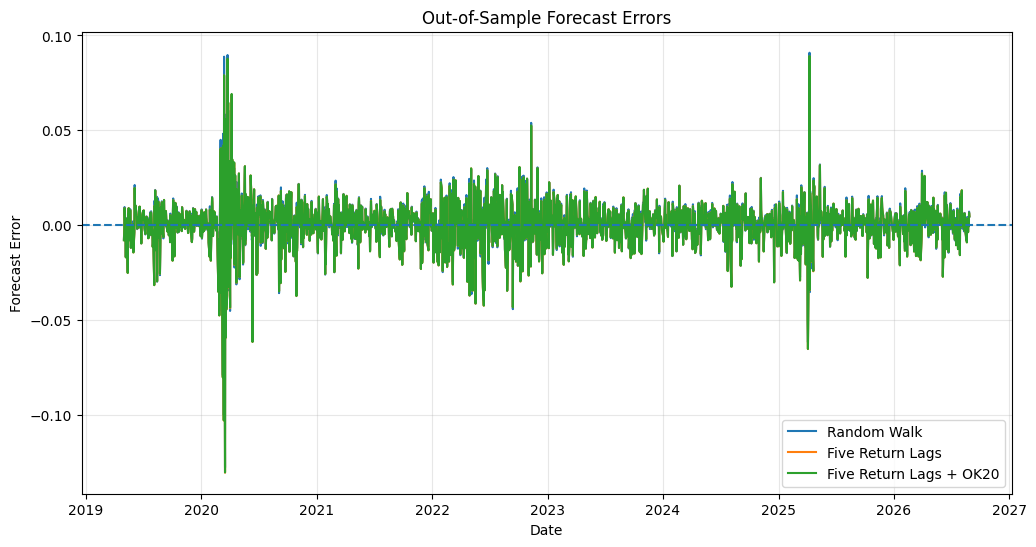

In [30]:
import matplotlib.pyplot as plt


# ============================================================
# OUT-OF-SAMPLE FORECAST ERRORS
# ============================================================

# Actual out-of-sample returns
actual_test = y_test_raw.to_numpy()

# ------------------------------------------------------------
# Random Walk forecast errors
# Forecast under random walk = 0
# ------------------------------------------------------------

error_random_walk = actual_test


# ------------------------------------------------------------
# Five-lag return model forecast errors
# ------------------------------------------------------------

error_base = (
    actual_test
    - base_results["predicted_test"]
)


# ------------------------------------------------------------
# Five return lags + OK20 forecast errors
# ------------------------------------------------------------

error_vol = (
    actual_test
    - vol_results["predicted_test"]
)


# ============================================================
# DATES FOR OUT-OF-SAMPLE TEST PERIOD
# ============================================================

test_dates = y_test_raw.index


# ============================================================
# PLOT FORECAST ERRORS
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    test_dates,
    error_random_walk,
    label="Random Walk"
)

plt.plot(
    test_dates,
    error_base,
    label="Five Return Lags"
)

plt.plot(
    test_dates,
    error_vol,
    label="Five Return Lags + OK20"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Out-of-Sample Forecast Errors"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Forecast Error"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

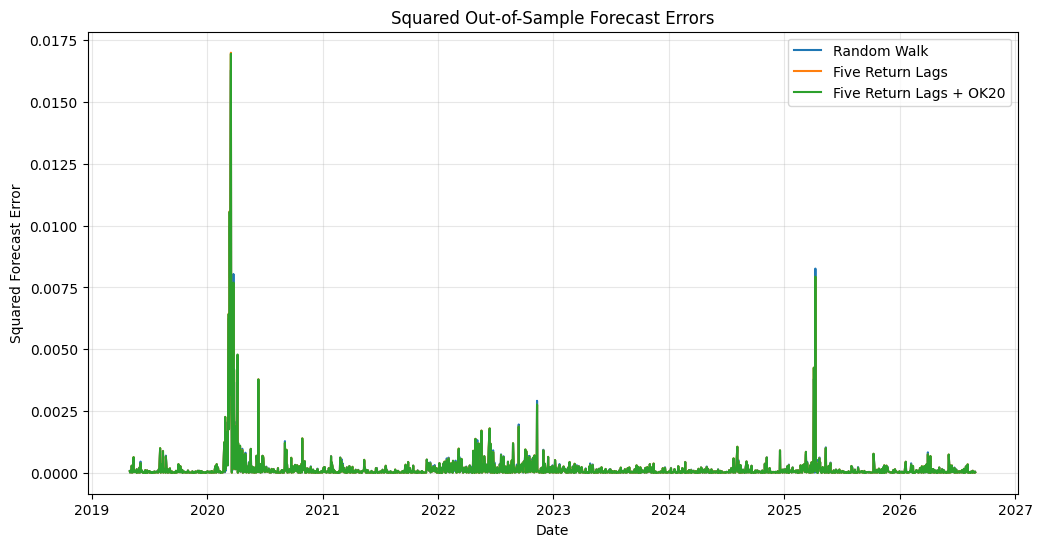

In [16]:
# ============================================================
# SQUARED OUT-OF-SAMPLE FORECAST ERRORS
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    test_dates,
    error_random_walk**2,
    label="Random Walk"
)

plt.plot(
    test_dates,
    error_base**2,
    label="Five Return Lags"
)

plt.plot(
    test_dates,
    error_vol**2,
    label="Five Return Lags + OK20"
)

plt.title(
    "Squared Out-of-Sample Forecast Errors"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Squared Forecast Error"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

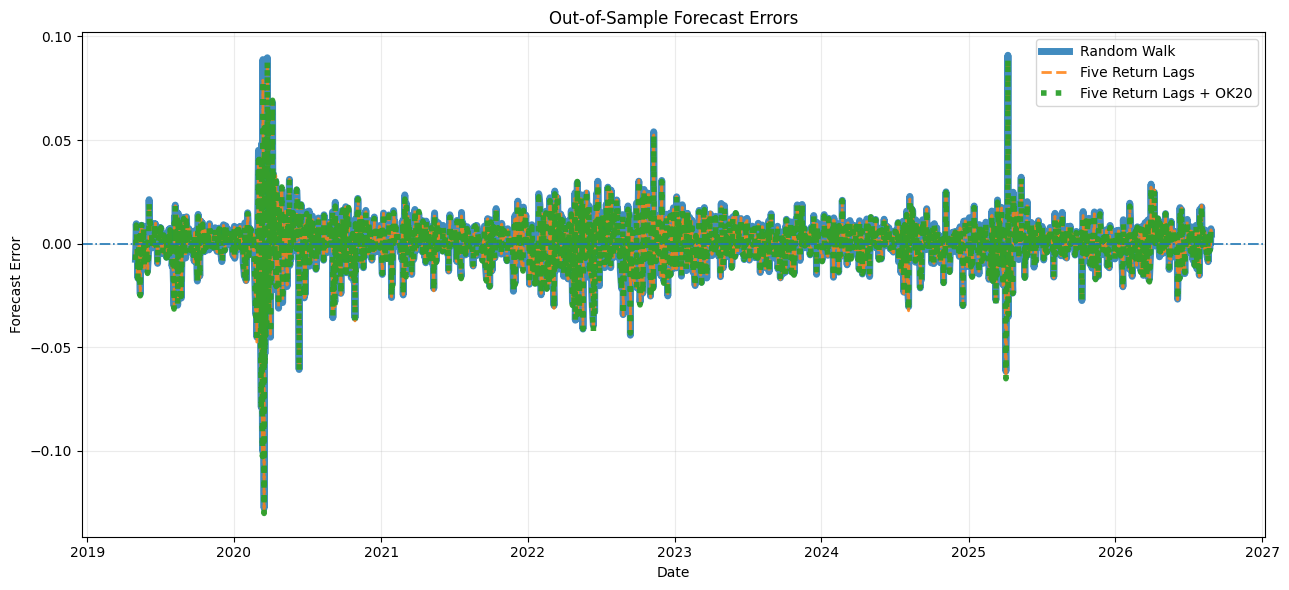

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 6))

# Random Walk
plt.plot(
    test_dates,
    error_random_walk,
    label="Random Walk",
    linestyle="-",
    linewidth=5,
    alpha=0.85
)

# Five Return Lags
plt.plot(
    test_dates,
    error_base,
    label="Five Return Lags",
    linestyle="--",
    linewidth=2.0,
    alpha=0.85
)

# Five Return Lags + OK20
plt.plot(
    test_dates,
    error_vol,
    label="Five Return Lags + OK20",
    linestyle=":",
    linewidth=4,
    alpha=0.95
)

# Zero line
plt.axhline(
    0,
    linestyle="-.",
    linewidth=1.2
)

plt.title(
    "Out-of-Sample Forecast Errors"
)

plt.xlabel("Date")
plt.ylabel("Forecast Error")

plt.legend(
    loc="upper right",
    frameon=True
)

plt.grid(
    True,
    alpha=0.25
)

plt.tight_layout()
plt.savefig(
    "forecast_errors.pdf",
    bbox_inches="tight"
)
plt.show()

## Major Out-of-Sample Forecast Errors and Associated Market Events

The largest out-of-sample forecast errors tend to occur during periods of exceptional financial-market volatility.

The table below identifies the likely major economic or financial event associated with each of the 15 largest random-walk forecast errors.

| Date           | S&P Return / RW Error (%) | Best Forecast Model | Likely Market Event                                                                                                                                                                                                                        |
| -------------- | ------------------------: | ------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **2020-03-16** |                    -12.77 | Random Walk         | **COVID-19 market crash.** The Federal Reserve had cut interest rates to near zero and announced large-scale asset purchases, but these actions failed to calm markets. The S&P 500 suffered its worst daily decline since the 1987 crash. |
| **2020-03-12** |                     -9.99 | Random Walk         | **COVID-19 panic and European travel restrictions.** Markets reacted sharply to the rapid global spread of COVID-19 and new U.S. restrictions on travel from Europe. A market-wide circuit breaker was triggered.                          |
| **2025-04-09** |                     +9.09 | AR(5)               | **Tariff-pause rebound.** President Trump announced a 90-day pause on many of the reciprocal tariffs announced the previous week. The announcement produced one of the largest one-day U.S. stock-market rallies in decades.               |
| **2020-03-24** |                     +8.97 | AR(5)               | **COVID fiscal and monetary-policy rebound.** Stocks surged on expectations of a roughly $2 trillion U.S. economic rescue package and extraordinary Federal Reserve support for financial markets.                                         |
| **2020-03-13** |                     +8.88 | AR(5)               | **COVID policy-response rebound.** President Trump declared a national emergency and announced additional measures to combat the pandemic, producing a very large late-day rally.                                                          |
| **2020-03-09** |                     -7.90 | Random Walk         | **COVID-19 fears combined with the Saudi-Russian oil-price war.** Oil prices collapsed after the breakdown of OPEC+ negotiations, adding an energy shock to growing fears of a global COVID recession.                                     |
| **2020-04-06** |                     +6.80 | Random Walk         | **Optimism that the first COVID wave might be peaking.** New infections and deaths showed signs of slowing in Italy, Spain, and New York, producing a strong global equity rally.                                                          |
| **2025-04-04** |                     -6.16 | Random Walk         | **Escalation of the 2025 tariff shock.** China announced retaliatory tariffs following the Trump administration's sweeping tariff announcement, increasing fears of a global trade war and recession.                                      |
| **2020-06-11** |                     -6.08 | Random Walk         | **Renewed COVID and recession fears.** Investors reacted to a pessimistic Federal Reserve economic outlook and growing concerns about a second wave of COVID infections.                                                                   |
| **2020-03-26** |                     +6.05 | Random Walk         | **CARES Act / stimulus rally.** The Senate passed a roughly $2 trillion coronavirus relief package. Stocks rose sharply despite a record increase in U.S. unemployment claims.                                                             |
| **2020-03-17** |                     +5.82 | AR(5)               | **Stimulus-policy rebound.** Expectations of a very large U.S. fiscal package, including direct payments to households, together with new Federal Reserve credit programs, produced a strong market rebound.                               |
| **2022-11-10** |                     +5.40 | AR(5)               | **Positive inflation surprise.** October CPI inflation came in below expectations, leading markets to anticipate that the Federal Reserve might slow the pace of monetary tightening.                                                      |
| **2020-03-18** |                     -5.32 | Random Walk         | **Renewed COVID liquidation and recession fears.** Evidence of an extraordinary global economic contraction intensified, while stress remained severe across equity, credit, commodity, and funding markets.                               |
| **2020-03-11** |                     -5.01 | AR(5)+OK20          | **WHO declares COVID-19 a global pandemic.** The market fell sharply as the economic consequences of the pandemic and widespread shutdowns became increasingly apparent.                                                                   |
| **2025-04-03** |                     -4.96 | Random Walk         | **Reaction to the April 2 "Liberation Day" tariff announcement.** The Trump administration announced sweeping new tariffs on U.S. trading partners, triggering fears of higher inflation, slower global growth, and a trade war.           |

---

## Interpretation

The extreme observations fall primarily into three major episodes:

### 1. COVID-19 Crisis: March--June 2020

Most of the largest forecast errors occurred during the extraordinary COVID-19 market disruption.

The period contained alternating episodes of

* panic selling,
* emergency Federal Reserve intervention,
* fiscal-policy announcements,
* enormous negative returns, and
* enormous positive rebound returns.

An especially interesting result is that the **random walk does not dominate throughout the COVID crisis**.

On several major negative market days, such as March 12 and March 16, the random walk produces the smallest forecast error.

However, on several major rebound days, including March 13, March 17, and March 24, the AR(5) model performs better.

Thus, relative forecasting performance changes even **within the same crisis episode**.

---

### 2. Inflation and Federal Reserve Tightening: 2022

The large positive observation on November 10, 2022 occurred when inflation data came in below expectations.

Markets interpreted the CPI report as evidence that inflation might finally be declining and that the Federal Reserve might therefore be able to reduce the pace of future interest-rate increases.

The AR(5) model performs better than the random walk on this date.

---

### 3. U.S. Tariff Shock: April 2025

The large 2025 observations are associated primarily with the Trump administration's new tariff policy rather than simply with the presidential inauguration in January.

The sequence was approximately

$$
\text{Tariff Announcement}
\rightarrow
\text{Large Market Decline}
\rightarrow
\text{Chinese Retaliation}
\rightarrow
\text{Further Market Stress}
\rightarrow
\text{Tariff Pause}
\rightarrow
\text{Large Market Rebound}.
$$

In particular,

* **April 3:** markets fell sharply following the April 2 announcement of sweeping U.S. tariffs;
* **April 4:** China announced retaliatory tariffs, intensifying trade-war fears;
* **April 9:** the announcement of a 90-day pause on many tariffs generated an exceptionally large market rebound.

Again, the same forecasting model does not dominate throughout the episode.

The random walk performs best on the large negative observations of April 3 and April 4, while the AR(5) model performs best during the enormous April 9 rebound.

---

## Main Forecasting Lesson

These results illustrate why a single full-sample RMSE may provide an incomplete description of forecasting performance.

A model may have the lowest RMSE on average but fail to dominate during every important market episode.

Conversely, a model with a slightly larger overall RMSE may outperform the benchmark during particular periods.

Thus,

$$
\text{Average Forecast Performance}
\neq
\text{Forecast Performance at Every Point in Time}.
$$

This provides motivation for examining **time variation in relative forecast performance**, rather than relying exclusively on a single full-sample measure such as RMSE.


### Does the Random Walk Always Forecast Best?

Although the random-walk model may produce the lowest RMSE over the full out-of-sample period, it does **not** provide the most accurate forecast on every date.

Among the 15 dates with the largest absolute random-walk forecast errors:

* the **Random Walk** has the smallest error on 9 dates,
* the **AR(5)** model has the smallest error on 5 dates,
* the **AR(5)+OK20** model has the smallest error on 1 date.

Thus,

$$
\text{best average forecasting model}
\neq
\text{best forecasting model at every point in time}.
$$

This distinction becomes especially interesting during periods of financial stress.

For example, during the COVID crisis the random walk performs relatively well on several of the large negative market declines. However, the AR(5) model performs better on several of the large positive rebound days.

The results therefore suggest that **relative forecasting performance varies over time**.

A model can have a lower RMSE over the complete test sample while another model may forecast more accurately during particular episodes.

This illustrates an important limitation of comparing forecasting models using only a single full-sample measure such as RMSE:

$$
RMSE
=
\sqrt{
\frac{1}{N^*}
\sum_{t^*=1}^{N^*}
e_{t^*}^2
}.
$$

RMSE summarizes average forecasting performance over the entire test period, but it does not reveal **when** one forecasting model performs better than another.

For this reason, it is also useful to examine the **relative forecast performance over time**.
